# Task 2: Exploratory Data Analysis (EDA)

Dataset: `Real_Estate_Dataset.xlsx` (100 properties across Pakistan, Italy, Australia)

## 1. Questions to answer before analysis

- Which country has the highest average property price?
- Does listing type (Sale vs Rent) differ by country?
- Does furnished status affect rent price?
- Is there a relationship between property age and price?
- Are there missing values, duplicates, or outlier prices that need fixing before deeper analysis?

## 2. Explore the data structure

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_excel("Real_Estate_Dataset.xlsx")
df.head()

,Property_ID,Property_Type,Listing_Type,Price,Currency,Area,Area_Unit,Bedrooms,Bathrooms,Year_Built,...,Monthly_Rental_Yield,Investment_Type,Zoning_Type,Energy_Rating,Balcony,Garden,Swimming_Pool,Elevator,Security,Internet_Availability
0,PROP-1001,Townhouse,Sale,184650134,PKR,5,Marla,5,4,1977,...,6.04,Residential,Commercial,D,No,No,Yes,Yes,No,Yes
1,PROP-1002,Townhouse,Rent,146942632,PKR,5,Marla,4,1,2010,...,5.22,Commercial,Commercial,C,No,Yes,No,Yes,Yes,Yes
2,PROP-1003,Townhouse,Rent,3472540,AUD,73,Sqm,2,1,1995,...,4.09,Residential,Agricultural,E,No,No,No,Yes,Yes,No
3,PROP-1004,Studio,Sale,106285188,PKR,15,Marla,5,4,2008,...,2.52,Mixed-Use,Agricultural,E,Yes,Yes,No,Yes,Yes,No
4,PROP-1005,Apartment,Sale,1602451,EUR,202,Sqm,2,1,1990,...,3.49,Mixed-Use,Industrial,B,Yes,No,No,No,No,No


In [2]:
# Shape and column types
print("Rows, Columns:", df.shape)
df.info()

Rows, Columns: (100, 41)
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            100 non-null    str    
 1   Property_Type          100 non-null    str    
 2   Listing_Type           100 non-null    str    
 3   Price                  100 non-null    int64  
 4   Currency               100 non-null    str    
 5   Area                   100 non-null    int64  
 6   Area_Unit              100 non-null    str    
 7   Bedrooms               100 non-null    int64  
 8   Bathrooms              100 non-null    int64  
 9   Year_Built             100 non-null    int64  
 10  Property_Age           100 non-null    int64  
 11  Furnished_Status       100 non-null    str    
 12  Condition              100 non-null    str    
 13  Parking_Spaces         100 non-null    int64  
 14  Location               100 non-null    str   

In [3]:
# Basic statistics for numeric columns
df.describe()

,Price,Area,Bedrooms,Bathrooms,Year_Built,Property_Age,Parking_Spaces,Postal_Code,Rent_Price,Property_Tax,Monthly_Rental_Yield
count,1.000000e+02,100.000000,100.000000,100.000000,100.00000,100.00000,100.000000,100.000000,4.700000e+01,1.000000e+02,100.000000
mean,5.333595e+07,142.430000,3.550000,2.600000,1998.49000,27.51000,1.560000,39533.450000,3.748846e+05,3.513880e+05,5.471700
std,7.677933e+07,131.986857,1.760251,1.310409,16.17736,16.17736,1.249808,33105.627458,5.250187e+05,5.350802e+05,1.606575
min,1.067750e+05,3.000000,1.000000,1.000000,1975.00000,1.00000,0.000000,2265.000000,2.509000e+03,6.030000e+02,2.520000
25%,1.563556e+06,12.000000,2.000000,1.000000,1981.00000,12.75000,0.000000,6113.750000,1.038450e+04,9.331500e+03,4.295000
50%,2.496208e+06,116.500000,3.000000,2.500000,1997.00000,29.00000,2.000000,30100.500000,1.797100e+04,1.941200e+04,5.470000
75%,1.059365e+08,261.750000,5.000000,3.250000,2013.25000,45.00000,2.000000,69255.000000,7.097055e+05,5.804388e+05,6.790000
max,2.444071e+08,398.000000,6.000000,5.000000,2025.00000,51.00000,4.000000,99399.000000,1.652714e+06,1.731988e+06,8.290000


In [4]:
# How many unique values does each column have (helps spot ID columns vs categories)
df.nunique().sort_values(ascending=False)

Property_ID              100
Price                    100
Address                  100
Property_Tax             100
Postal_Code              100
Agent_ID                 100
Description               98
Monthly_Rental_Yield      88
Agent_Name                84
Area                      67
Location                  59
Neighborhood              57
Rent_Price                47
Property_Age              42
Year_Built                42
Sale_Date                 34
City                      15
Agency_Name               15
State                     13
Property_Type              7
Bedrooms                   6
Parking_Spaces             5
Energy_Rating              5
Bathrooms                  5
Condition                  4
Zoning_Type                4
Property_Status            4
Currency                   3
Furnished_Status           3
Investment_Type            3
Owner_Type                 3
Country                    3
Listing_Type               2
Area_Unit                  2
Ownership_Stat

## 3. Trends, patterns and anomalies

Since prices are in three different currencies (PKR, EUR, AUD), comparing raw `Price`
across countries is misleading. So instead we look at patterns *within* each country,
and use `Monthly_Rental_Yield` (a percentage, already comparable) for cross-country comparison.

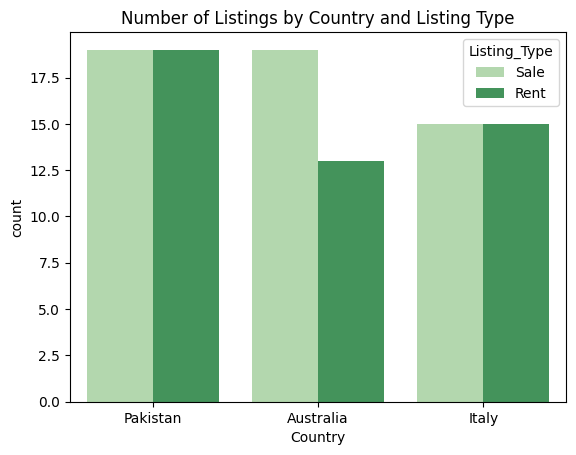

In [5]:
# Listings by country and type
sns.countplot(data=df, x="Country", hue="Listing_Type", palette="Greens")
plt.title("Number of Listings by Country and Listing Type")
plt.show()

**Observation:** shows whether Sale or Rent listings dominate in each country, and
whether one country simply has more total listings than the others.

In [6]:
# Average rental yield by country (safe to compare - it's a percentage, not currency)
df.groupby("Country")["Monthly_Rental_Yield"].mean().sort_values(ascending=False)

Country
Pakistan     5.714211
Australia    5.692188
Italy        4.929333
Name: Monthly_Rental_Yield, dtype: float64

**Observation:** compares expected rental return by country without currency distortion.

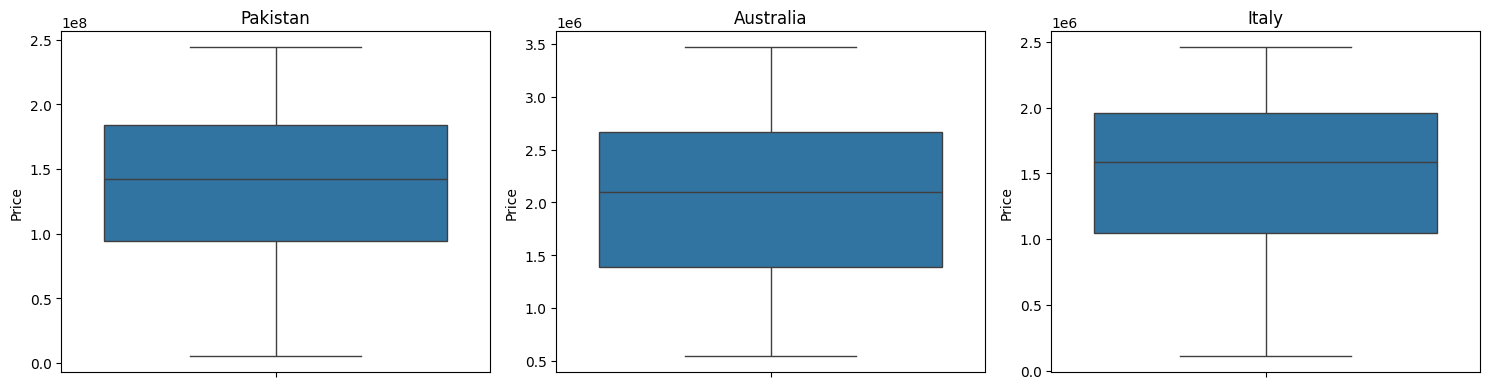

In [7]:
# Price distribution WITHIN each country (spot outliers per currency)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, country in zip(axes, df["Country"].unique()):
    sns.boxplot(data=df[df["Country"] == country], y="Price", ax=ax)
    ax.set_title(country)
plt.tight_layout()
plt.show()

**Observation:** boxplots show the price spread inside each country separately.
Any dot far above the box is a property priced well above the rest of that country's
listings - worth checking if it's a genuine luxury property or a data entry error.

## 4. Test hypotheses and validate assumptions

**Hypothesis 1:** Furnished properties have higher rent prices than unfurnished ones.

In [8]:
rent_df = df[df["Listing_Type"] == "Rent"]

furnished = rent_df[rent_df["Furnished_Status"] == "Furnished"]["Rent_Price"].dropna()
unfurnished = rent_df[rent_df["Furnished_Status"] == "Unfurnished"]["Rent_Price"].dropna()

t_stat, p_value = stats.ttest_ind(furnished, unfurnished, equal_var=False)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Result: statistically significant difference between furnished and unfurnished rent prices.")
else:
    print("Result: no statistically significant difference (with this sample size).")

T-statistic: 0.45, P-value: 0.656
Result: no statistically significant difference (with this sample size).


**Hypothesis 2:** Property age is related to price (older properties are cheaper).

Correlation between Property Age and Price: -0.039


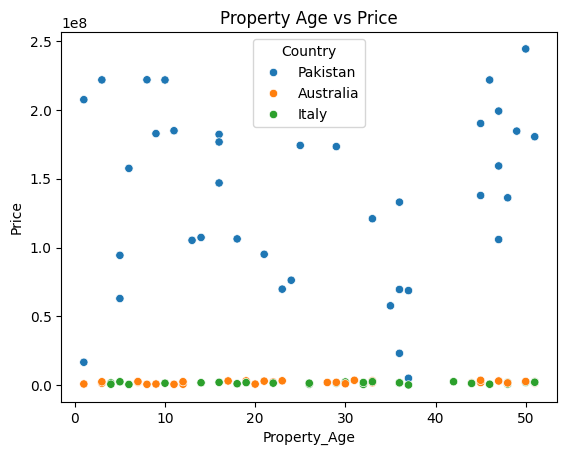

In [9]:
corr = df["Property_Age"].corr(df["Price"])
print(f"Correlation between Property Age and Price: {corr:.3f}")

sns.scatterplot(data=df, x="Property_Age", y="Price", hue="Country")
plt.title("Property Age vs Price")
plt.show()

**Observation:** a correlation near 0 means age and price are not linearly related in
this dataset (expected here since this is synthetic data - on a real dataset this test
would carry more meaning).

## 5. Detect data issues

In [10]:
# Missing values per column
missing = df.isnull().sum()
missing[missing > 0]

Sale_Date     65
Rent_Price    53
dtype: int64

In [11]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Data issues found / to address before further analysis:**

- **Currency mismatch:** `Price` and `Rent_Price` are in three different currencies (PKR, EUR, AUD).
  They must be converted to one common currency before any direct price comparison across countries.
- **Missing Rent_Price:** blank for every row where `Listing_Type` is "Sale" - this is expected,
  not an error, but should be handled (e.g. excluded) in rent-specific analysis.
- **Missing Sale_Date:** blank unless `Property_Status` is "Sold" - same as above, expected but
  needs filtering before any date-based analysis.
- **Outlier prices:** flagged visually in the boxplots above - should be checked row by row
  before being included in any average or model.